# **Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.colors import LogNorm
import seaborn as sns
import matplotlib.lines as mlines
pd.options.mode.chained_assignment = None
pd.set_option('display.max_columns', None)

# **Import tracks data for APERO cruise**

In [2]:
# import the corrected and selected tracks for APERO
APERO_tracks = pd.read_csv('/home/aaccardo/these_alex/Papers/Rising_stars/Data/Vertical_speeds/APERO_selected_tracks_by_interquartile_poly_no_living.csv')
APERO_tracks = APERO_tracks.drop(columns=['Unnamed: 0'])
APERO_tracks['cruise'] = 'APERO'
APERO_tracks['zone'] = 'North Atlantic'
APERO_tracks

,pred_poly,sequence,track_id,vertical_speed,size_um,meangrey,time,error,mse,rmse,r2,perim_px,area_um,esd_um,major_px,minor_px,perimmajor,stdgrey,cvgrey,intgrey,mediangrey,mingrey,maxgrey,rangegrey,area_convex,eccentricity,extent,solidity,track_count,corrected_by_poly,Q1,Q3,upper_bound,lower_bound,object_annotation_category,cruise,zone
0,-47.997545,20230611-002733,APERO_C1_20230611-002816-1-916,27.067691,246.547642,63.023866,25.400000,75.065237,1293.285094,35.962273,0.556984,12.525483,48538.074003,246.547642,6.792744,2.980531,1.851820,26.766581,42.501572,923.600000,60.200000,25.600000,114.200000,88.600000,17.600000,0.889301,0.570833,0.827087,695,75.065237,-19.573616,17.995637,74.349515,-75.927494,not-living,APERO,North Atlantic
1,-47.035952,20230611-002733,APERO_C1_20230611-002829-1-1435,31.555337,1035.906803,104.796561,42.428571,78.591289,1293.285094,35.962273,0.556984,55.320601,859557.536536,1035.906803,19.853928,11.867176,2.787027,53.461416,51.070820,19810.642857,100.250000,23.071429,223.785714,200.714286,201.928571,0.802409,0.672769,0.899479,695,78.591289,-19.573616,17.995637,74.349515,-75.927494,not-living,APERO,North Atlantic
2,-46.920249,20230611-002733,APERO_C1_20230611-002834-1-1578,51.631967,108.968921,55.305556,44.000000,98.552216,1293.285094,35.962273,0.556984,3.475353,9388.330656,108.968921,2.370224,1.451709,1.539296,19.318232,35.143488,190.888889,52.333333,33.777778,81.111111,47.333333,3.444444,0.561840,0.851852,1.000000,695,98.552216,-19.573616,17.995637,74.349515,-75.927494,not-living,APERO,North Atlantic
3,-41.519202,20230611-002733,APERO_C1_20230611-002907-2-2931,40.011558,136.415389,73.325735,89.970588,81.530760,1293.285094,35.962273,0.556984,5.232517,14976.206705,136.415389,2.906261,2.001715,1.809873,28.821153,39.807768,385.529412,70.779412,36.352941,114.441176,78.088235,5.294118,0.581690,0.853758,0.981338,695,81.530760,-19.573616,17.995637,74.349515,-75.927494,not-living,APERO,North Atlantic
4,-40.571366,20230611-002733,APERO_C1_20230611-002918-1-3368,48.514431,124.092221,72.480258,95.708333,89.085797,1293.285094,35.962273,0.556984,4.511845,12366.940032,124.092221,2.437109,1.912335,1.863164,28.867687,40.780294,319.833333,70.270833,37.750000,114.166667,76.416667,4.375000,0.360660,0.868056,1.000000,695,89.085797,-19.573616,17.995637,74.349515,-75.927494,not-living,APERO,North Atlantic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
791,86.862360,20230713-042803,APERO_C5_20230713-043248-1-8413,149.314402,859.596554,81.899763,261.384615,62.452042,569.800296,23.870490,0.887168,72.414924,582002.226297,859.596554,24.930501,10.582206,2.904711,36.067138,43.897118,10766.538462,81.923077,23.230769,167.615385,144.384615,217.307692,0.904952,0.410473,0.600251,551,62.452042,-14.625216,13.453793,55.572305,-56.743728,not-living,APERO,North Atlantic
792,94.602154,20230713-042803,APERO_C5_20230713-043301-1-8717,169.000999,239.397542,53.623205,274.000000,74.398845,569.800296,23.870490,0.887168,12.866225,50557.019943,239.397542,7.284838,2.913288,1.671898,33.266155,60.209407,832.846154,42.307692,24.769231,144.307692,119.538462,19.846154,0.859600,0.539977,0.786790,551,74.398845,-14.625216,13.453793,55.572305,-56.743728,not-living,APERO,North Atlantic
793,106.876513,20230713-042803,APERO_C5_20230713-043322-1-9208,171.007026,402.057780,91.429246,294.500000,64.130513,569.800296,23.870490,0.887168,21.368446,127511.038493,402.057780,8.258849,5.591207,2.588733,43.980739,48.059479,3149.083333,91.125000,24.500000,176.166667,151.666667,38.583333,0.732405,0.655357,0.888611,551,64.130513,-14.625216,13.453793,55.572305,-56.743728,not-living,APERO,North Atlantic
794,144.642565,20230713-042803,APERO_C5_20230713-043431-1-11126,84.461913,165.521745,39.600017,362.000000,-60.180652,569.800296,23.870490,0.887168,7.230796,22799.832971,165.521745,4.296724,2.222534,1.708472,14.111826,34.045029,315.222222,37.000000,23.888889,64.555556,40.666667,9.000

# **Add depth**

In [3]:
# import the depth of each sequence 
seq_depth = pd.read_csv('/home/aaccardo/these_alex/Papers/Rising_stars/Data/TZEX_parking_depths/TZEX_parking_depth_APERO.csv', delimiter = ';')
seq_depth = seq_depth.dropna(subset=['date_ini']) 
seq_depth = seq_depth[seq_depth['flag'] != 'not_good']
seq_depth["date_ini"] = pd.to_datetime(seq_depth["date_ini"], format="%d/%m/%Y %H:%M")
seq_depth["date_fin"] = pd.to_datetime(seq_depth["date_fin"], format="%d/%m/%Y %H:%M")
seq_depth['seq_ini'] = seq_depth['date_ini'].dt.strftime('%Y%m%d-%H%M%S')
seq_depth['seq_fin'] = seq_depth['date_fin'].dt.strftime('%Y%m%d-%H%M%S')
seq_depth["seq_ini"] = pd.to_datetime(seq_depth["seq_ini"], format="%Y%m%d-%H%M%S")
seq_depth["seq_fin"] = pd.to_datetime(seq_depth["seq_fin"], format="%Y%m%d-%H%M%S")
seq_depth['cycle'] = 'APERO_' + seq_depth['cycle'].astype(str)
seq_depth.rename(columns={'cycle': 'Cycle'}, inplace=True)
seq_depth.rename(columns={'date_ini': 'parking_start'}, inplace=True)
seq_depth.rename(columns={'date_fin': 'parking_end'}, inplace=True)
seq_depth['img_nb'] = seq_depth['img_nb'].astype(int)
seq_depth = seq_depth.drop('img_nb', axis=1)
tzex_parking_APERO = seq_depth
tzex_parking_APERO['depth'] = tzex_parking_APERO['depth'].astype(str).str.replace(r'_\d', '', regex=True).astype(int)
tzex_parking_APERO

,Cycle,depth,parking_start,parking_end,flag,seq_ini,seq_fin
0,APERO_C1,200,2023-06-10 23:43:00,2023-06-11 05:36:00,good,2023-06-10 23:43:00,2023-06-11 05:36:00
4,APERO_C2,500,2023-06-17 17:15:00,2023-06-17 23:11:00,medium_good,2023-06-17 17:15:00,2023-06-17 23:11:00
5,APERO_C2,1000,2023-06-18 09:25:00,2023-06-19 04:56:00,good,2023-06-18 09:25:00,2023-06-19 04:56:00
7,APERO_C3,500,2023-06-24 19:36:00,2023-06-25 00:07:00,medium_good,2023-06-24 19:36:00,2023-06-25 00:07:00
8,APERO_C3,1000,2023-06-25 11:25:00,2023-06-26 05:56:00,good,2023-06-25 11:25:00,2023-06-26 05:56:00
10,APERO_C4,500,2023-07-03 19:58:00,2023-07-04 04:28:00,good,2023-07-03 19:58:00,2023-07-04 04:28:00
12,APERO_C5,1000,2023-07-10 22:21:00,2023-07-11 11:55:00,good,2023-07-10 22:21:00,2023-07-11 11:55:00
13,APERO_C5,300,2023-07-12 10:18:00,2023-07-12 16:53:00,medium_good,2023-07-12 10:18:00,2023-07-12 16:53:00
14,APERO_C5,300,2023-07-12 21:39:00,2023-07-13 04:40:00,medium_good,2023-07-12 21:39:00,2023-07-13 04:40:00


In [4]:
desc_depth = APERO_tracks[APERO_tracks['corrected_by_poly'] > 0]
desc_depth['datetime'] = pd.to_datetime(desc_depth['sequence'], format='%Y%m%d-%H%M%S')
print(desc_depth[['datetime']])
desc_depth

               datetime
0   2023-06-11 00:27:33
1   2023-06-11 00:27:33
2   2023-06-11 00:27:33
3   2023-06-11 00:27:33
4   2023-06-11 00:27:33
..                  ...
790 2023-07-13 04:28:03
791 2023-07-13 04:28:03
792 2023-07-13 04:28:03
793 2023-07-13 04:28:03
795 2023-07-13 04:28:03

[487 rows x 1 columns]


,pred_poly,sequence,track_id,vertical_speed,size_um,meangrey,time,error,mse,rmse,r2,perim_px,area_um,esd_um,major_px,minor_px,perimmajor,stdgrey,cvgrey,intgrey,mediangrey,mingrey,maxgrey,rangegrey,area_convex,eccentricity,extent,solidity,track_count,corrected_by_poly,Q1,Q3,upper_bound,lower_bound,object_annotation_category,cruise,zone,datetime
0,-47.997545,20230611-002733,APERO_C1_20230611-002816-1-916,27.067691,246.547642,63.023866,25.400000,75.065237,1293.285094,35.962273,0.556984,12.525483,48538.074003,246.547642,6.792744,2.980531,1.851820,26.766581,42.501572,923.600000,60.200000,25.600000,114.200000,88.600000,17.600000,0.889301,0.570833,0.827087,695,75.065237,-19.573616,17.995637,74.349515,-75.927494,not-living,APERO,North Atlantic,2023-06-11 00:27:33
1,-47.035952,20230611-002733,APERO_C1_20230611-002829-1-1435,31.555337,1035.906803,104.796561,42.428571,78.591289,1293.285094,35.962273,0.556984,55.320601,859557.536536,1035.906803,19.853928,11.867176,2.787027,53.461416,51.070820,19810.642857,100.250000,23.071429,223.785714,200.714286,201.928571,0.802409,0.672769,0.899479,695,78.591289,-19.573616,17.995637,74.349515,-75.927494,not-living,APERO,North Atlantic,2023-06-11 00:27:33
2,-46.920249,20230611-002733,APERO_C1_20230611-002834-1-1578,51.631967,108.968921,55.305556,44.000000,98.552216,1293.285094,35.962273,0.556984,3.475353,9388.330656,108.968921,2.370224,1.451709,1.539296,19.318232,35.143488,190.888889,52.333333,33.777778,81.111111,47.333333,3.444444,0.561840,0.851852,1.000000,695,98.552216,-19.573616,17.995637,74.349515,-75.927494,not-living,APERO,North Atlantic,2023-06-11 00:27:33
3,-41.519202,20230611-002733,APERO_C1_20230611-002907-2-2931,40.011558,136.415389,73.325735,89.970588,81.530760,1293.285094,35.962273,0.556984,5.232517,14976.206705,136.415389,2.906261,2.001715,1.809873,28.821153,39.807768,385.529412,70.779412,36.352941,114.441176,78.088235,5.294118,0.581690,0.853758,0.981338,695,81.530760,-19.573616,17.995637,74.349515,-75.927494,not-living,APERO,North Atlantic,2023-06-11 00:27:33
4,-40.571366,20230611-002733,APERO_C1_20230611-002918-1-3368,48.514431,124.092221,72.480258,95.708333,89.085797,1293.285094,35.962273,0.556984,4.511845,12366.940032,124.092221,2.437109,1.912335,1.863164,28.867687,40.780294,319.833333,70.270833,37.750000,114.166667,76.416667,4.375000,0.360660,0.868056,1.000000,695,89.085797,-19.573616,17.995637,74.349515,-75.927494,not-living,APERO,North Atlantic,2023-06-11 00:27:33
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
790,81.012617,20230713-042803,APERO_C5_20230713-043241-1-8237,191.497629,660.835552,116.316923,252.000000,110.485012,569.800296,23.870490,0.887168,34.892953,367079.212921,660.835552,13.620129,7.851961,2.549198,56.633376,47.457715,10631.222222,125.111111,24.777778,203.777778,179.000000,94.888889,0.790641,0.720223,0.899664,551,110.485012,-14.625216,13.453793,55.572305,-56.743728,not-living,APERO,North Atlantic,2023-07-13 04:28:03
791,86.862360,20230713-042803,APERO_C5_20230713-043248-1-8413,149.314402,859.596554,81.899763,261.384615,62.452042,569.800296,23.870490,0.887168,72.414924,582002.226297,859.596554,24.930501,10.582206,2.904711,36.067138,43.897118,10766.538462,81.923077,23.230769,167.615385,144.384615,217.307692,0.904952,0.410473,0.600251,551,62.452042,-14.625216,13.453793,55.572305,-56.743728,not-living,APERO,North Atlantic,2023-07-13 04:28:03
792,94.602154,20230713-042803,APERO_C5_20230713-043301-1-8717,169.000999,239.397542,53.623205,274.000000,74.398845,569.800296,23.870490,0.887168,12.866225,50557.019943,239.397542,7.284838,2.913288,1.671898,33.266155,60.209407,832.846154,42.307692,24.769231,144.307692,119.538462,19.846154,0.859600,0.539977,0.786790,551,74.398845,-14.625216,13.453793,55.572305,-56.743728,not-living,APERO,North Atlantic,2023-07-13 04:28:03
793,106.876513,20230713-042803,APERO_C5_20230713-043322-1-9208,171.007026,402.057780,91.429246,294.500000

In [5]:
# Function to find the matching depth based on datetime range
def find_depth(row):
    # Find the row in tzex_parking where the datetime falls within the range
    match = tzex_parking_APERO[(tzex_parking_APERO['seq_ini'] <= row['datetime']) &
                         (tzex_parking_APERO['seq_fin'] >= row['datetime'])]
    # Return the depth if there's a match, else NaN
    return match['depth'].values[0] if not match.empty else None

# Apply the function to add the depth column to desc
desc_depth['depth'] = desc_depth.apply(find_depth, axis=1)
desc_depth = desc_depth.dropna(subset=['depth'])
desc_depth['depth'] = desc_depth['depth'].astype(int)
desc_depth['depth'] = desc_depth['depth'].astype(str)
desc_depth_APERO = desc_depth
desc_depth_APERO['depth'].unique()

array(['200', '500', '1000', '300'], dtype=object)

# **Do the same for ascending particles**

In [6]:
asc_depth = APERO_tracks[APERO_tracks['corrected_by_poly'] < 0]
asc_depth['datetime'] = pd.to_datetime(asc_depth['sequence'], format='%Y%m%d-%H%M%S')
print(asc_depth[['datetime']])

               datetime
13  2023-06-11 00:27:33
15  2023-06-11 00:27:33
17  2023-06-11 00:27:33
18  2023-06-11 00:27:33
20  2023-06-11 00:27:33
..                  ...
780 2023-07-13 02:48:03
783 2023-07-13 02:48:03
784 2023-07-13 04:28:03
786 2023-07-13 04:28:03
794 2023-07-13 04:28:03

[309 rows x 1 columns]


In [7]:
# Function to find the matching depth based on datetime range
def find_depth(row):
    # Find the row in tzex_parking where the datetime falls within the range
    match = tzex_parking_APERO[(tzex_parking_APERO['seq_ini'] <= row['datetime']) &
                         (tzex_parking_APERO['seq_fin'] >= row['datetime'])]
    # Return the depth if there's a match, else NaN
    return match['depth'].values[0] if not match.empty else None

# Apply the function to add the depth column to desc
asc_depth['depth'] = asc_depth.apply(find_depth, axis=1)
asc_depth = asc_depth.dropna(subset=['depth'])
asc_depth['depth'] = asc_depth['depth'].astype(int)
asc_depth['depth'] = asc_depth['depth'].astype(str)
asc_depth_APERO = asc_depth
asc_depth['depth'].unique()

array(['200', '500', '1000', '300'], dtype=object)

# **Compute the number of particles for each size class for ascending and descending categories**

In [8]:
# for descending ones 
nb_part_desc = desc_depth_APERO.groupby('depth').size().reset_index(name='desc_count')
# Sort by depth
nb_part_desc['depth'] = nb_part_desc['depth'].astype(int)
nb_part_desc = nb_part_desc.sort_values(by='depth')
nb_part_desc

,depth,desc_count
1,200,41
2,300,63
3,500,107
0,1000,228


In [9]:
# for ascending ones 
nb_part_asc = asc_depth_APERO.groupby('depth').size().reset_index(name='asc_count')
# Sort by depth
nb_part_asc['depth'] = nb_part_asc['depth'].astype(int)
nb_part_asc = nb_part_asc.sort_values(by='depth')
nb_part_asc

,depth,asc_count
1,200,36
2,300,37
3,500,55
0,1000,124


In [10]:
nb_part_tot = pd.merge(nb_part_desc, nb_part_asc, on = 'depth')
nb_part_tot

,depth,desc_count,asc_count
0,200,41,36
1,300,63,37
2,500,107,55
3,1000,228,124


In [11]:
nb_part_tot['nb_part_tot'] = nb_part_tot['desc_count'] + nb_part_tot['asc_count']
nb_part_tot['asc_prop_%'] = (nb_part_tot['asc_count']*100)/nb_part_tot['nb_part_tot']
nb_part_tot['desc_prop_%'] = (nb_part_tot['desc_count']*100)/nb_part_tot['nb_part_tot']
nb_part_tot = nb_part_tot[nb_part_tot['depth'] != 700]
nb_part_tot_APERO = nb_part_tot
nb_part_tot_APERO

,depth,desc_count,asc_count,nb_part_tot,asc_prop_%,desc_prop_%
0,200,41,36,77,46.753247,53.246753
1,300,63,37,100,37.000000,63.000000
2,500,107,55,162,33.950617,66.049383
3,1000,228,124,352,35.227273,64.772727


# **Import tracks data for VLFR**

In [12]:
VLFR_tracks = pd.read_csv('/home/aaccardo/these_alex/Papers/Rising_stars/Data/Vertical_speeds/VLFR_selected_tracks_by_interquartile_poly_no_living.csv')
VLFR_tracks['cruise'] = 'vlfr'
VLFR_tracks['zone'] = 'Mediterranean Sea'
VLFR_tracks

,pred_poly,sequence,track_id,vertical_speed,size_um,meangrey,time,error,mse,rmse,r2,perim_px,area_um,esd_um,major_px,minor_px,perimmajor,stdgrey,cvgrey,intgrey,mediangrey,mingrey,maxgrey,rangegrey,area_convex,eccentricity,extent,solidity,track_count,corrected_by_poly,Q1,Q3,upper_bound,lower_bound,object_annotation_category,cruise,zone
0,167.671521,20230418-142321,vlfr_20230418-142403-1-418,94.296297,114.971982,54.343333,22.000000,-73.375225,660.192273,25.694207,0.588969,4.214214,10511.082352,114.971982,2.756337,1.484728,1.527067,17.261139,35.035069,200.000000,52.900000,34.800000,76.800000,42.000000,3.800000,0.832847,0.733333,1.000000,152,-73.375225,-16.536293,13.132384,57.635401,-61.039310,detritus,vlfr,Mediterranean Sea
1,166.317665,20230418-142321,vlfr_20230418-142413-1-608,258.038728,455.286457,99.981881,39.500000,91.721063,660.192273,25.694207,0.588969,23.780866,165885.520336,455.286457,8.798337,6.359408,2.686349,54.308297,54.193766,4319.650000,95.875000,24.300000,196.950000,172.650000,48.850000,0.685007,0.689685,0.893653,152,91.721063,-16.536293,13.132384,57.635401,-61.039310,detritus,vlfr,Mediterranean Sea
2,164.584620,20230418-142321,vlfr_20230418-142426-1-958,228.438677,304.382251,74.276076,57.500000,63.854057,660.192273,25.694207,0.588969,16.454892,73172.536294,304.382251,7.618501,3.825806,2.162067,32.602755,43.467906,1573.900000,72.466667,25.266667,131.800000,106.533333,25.100000,0.859971,0.658710,0.838654,152,63.854057,-16.536293,13.132384,57.635401,-61.039310,detritus,vlfr,Mediterranean Sea
3,158.741302,20230418-142321,vlfr_20230418-142511-1-2256,236.135415,363.951173,97.182311,102.500000,77.394113,660.192273,25.694207,0.588969,18.018411,106376.804184,363.951173,7.179743,5.181784,2.494909,47.257284,48.446262,2902.100000,96.866667,25.066667,176.000000,150.933333,31.266667,0.683738,0.759087,0.929594,152,77.394113,-16.536293,13.132384,57.635401,-61.039310,detritus,vlfr,Mediterranean Sea
4,147.674681,20230418-142321,vlfr_20230418-142605-1-3707,215.745130,496.847746,89.540776,162.125000,68.070449,660.192273,25.694207,0.588969,26.180282,196658.316651,496.847746,9.056392,7.349353,2.880501,35.182899,39.581544,4487.925000,93.787500,25.275000,156.850000,131.575000,56.775000,0.565832,0.708847,0.880709,152,68.070449,-16.536293,13.132384,57.635401,-61.039310,detritus,vlfr,Mediterranean Sea
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
461,-84.057856,20230501-231319,vlfr_20230501-231957-1-10371,-140.192296,195.102155,73.021077,376.500000,-56.134440,378.987625,19.467604,0.615935,8.781092,30191.027904,195.102155,4.147502,2.918092,2.116595,33.204497,44.742046,709.375000,68.375000,27.875000,129.875000,102.000000,10.000000,0.682493,0.785764,0.963542,409,-56.134440,-9.562395,7.429199,32.916589,-35.049785,detritus,vlfr,Mediterranean Sea
462,-85.285975,20230501-231319,vlfr_20230501-232003-1-10572,-154.435880,205.712784,68.098055,383.444444,-69.149905,378.987625,19.467604,0.615935,9.418162,33517.908728,205.712784,5.373178,2.573705,1.754223,29.566250,43.793047,718.666667,64.611111,28.333333,123.444444,95.111111,12.000000,0.873998,0.737037,0.879361,409,-69.149905,-9.562395,7.429199,32.916589,-35.049785,detritus,vlfr,Mediterranean Sea
463,-85.481231,20230501-231319,vlfr_20230501-232004-1-10588,-141.559343,191.745555,88.308025,384.555556,-56.078112,378.987625,19.467604,0.615935,8.694304,29664.313902,191.745555,4.250962,2.686470,2.037128,47.433904,54.196583,832.444444,84.055556,27.111111,170.111111,143.000000,9.666667,0.746105,0.803704,0.984127,409,-56.078112,-9.562395,7.429199,32.916589,-35.049785,detritus,vlfr,Mediterranean Sea
464,-85.699511,20230501-231319,vlfr_20230501-232007-1-10668,-48.941032,124.717871,64.120000,385.800000,36.758480,378.987625,19.467604,0.615935,4.648528,12430.275503,124.717871,2.700440,1.770848,1.725997,29.818883,45.671808,287.000000,59.200000,30.000000,101.400000,71.400000,4.400000,0.642826,0.850000,1.000000,409

# **Add depth**

In [13]:
# import the depth of each sequence 
seq_depth = pd.read_csv('/home/aaccardo/these_alex/Papers/Rising_stars/Data/TZEX_parking_depths/TZEX_parking_depth_vlfr.csv', delimiter = ';')
seq_depth = seq_depth.dropna(subset=['date_ini']) 
seq_depth = seq_depth[seq_depth['flag'] != 'not_good']
seq_depth["date_ini"] = pd.to_datetime(seq_depth["date_ini"], format="%d/%m/%Y %H:%M")
seq_depth["date_fin"] = pd.to_datetime(seq_depth["date_fin"], format="%d/%m/%Y %H:%M")
seq_depth['seq_ini'] = seq_depth['date_ini'].dt.strftime('%Y%m%d-%H%M%S')
seq_depth['seq_fin'] = seq_depth['date_fin'].dt.strftime('%Y%m%d-%H%M%S')
seq_depth["seq_ini"] = pd.to_datetime(seq_depth["seq_ini"], format="%Y%m%d-%H%M%S")
seq_depth["seq_fin"] = pd.to_datetime(seq_depth["seq_fin"], format="%Y%m%d-%H%M%S")
seq_depth['cycle'] = 'VLFR_' + seq_depth['cycle'].astype(str)
seq_depth.rename(columns={'cycle': 'Cycle'}, inplace=True)
seq_depth.rename(columns={'date_ini': 'parking_start'}, inplace=True)
seq_depth.rename(columns={'date_fin': 'parking_end'}, inplace=True)
#seq_depth['img_nb'] = seq_depth['img_nb'].astype(int)
tzex_parking_VLFR = seq_depth
tzex_parking_VLFR['depth'] = tzex_parking_VLFR['depth'].astype(str).str.replace(r'_\d', '', regex=True).astype(int)
tzex_parking_VLFR

,Cycle,depth,parking_start,parking_end,flag,seq_ini,seq_fin
0,VLFR_C1,700,2023-04-18 12:54:00,2023-04-19 06:25:00,medium_good,2023-04-18 12:54:00,2023-04-19 06:25:00
1,VLFR_C1,500,2023-04-19 20:03:00,2023-04-20 00:33:00,good,2023-04-19 20:03:00,2023-04-20 00:33:00
2,VLFR_C1,300,2023-04-21 03:44:00,2023-04-21 20:15:00,good,2023-04-21 03:44:00,2023-04-21 20:15:00
3,VLFR_C1,200,2023-04-22 08:02:00,2023-04-23 02:33:00,good,2023-04-22 08:02:00,2023-04-23 02:33:00
4,VLFR_C1,500,2023-04-23 11:35:00,2023-04-24 01:06:00,medium_good,2023-04-23 11:35:00,2023-04-24 01:06:00
5,VLFR_C1,1000,2023-04-25 03:59:00,2023-04-26 05:00:00,medium_good,2023-04-25 03:59:00,2023-04-26 05:00:00
6,VLFR_C2,200,2023-04-28 00:00:00,2023-04-29 00:01:00,good,2023-04-28 00:00:00,2023-04-29 00:01:00
7,VLFR_C2,500,2023-04-29 09:04:00,2023-04-30 05:35:00,good,2023-04-29 09:04:00,2023-04-30 05:35:00
8,VLFR_C2,1000,2023-05-01 05:54:00,2023-05-02 06:55:00,medium_good,2023-05-01 05:54:00,2023-05-02 06:55:00


In [14]:
desc_depth = VLFR_tracks[VLFR_tracks['corrected_by_poly'] > 0]
desc_depth['datetime'] = pd.to_datetime(desc_depth['sequence'], format='%Y%m%d-%H%M%S')
print(desc_depth[['datetime']])
desc_depth

               datetime
1   2023-04-18 14:23:21
2   2023-04-18 14:23:21
3   2023-04-18 14:23:21
4   2023-04-18 14:23:21
5   2023-04-18 14:23:21
..                  ...
456 2023-05-01 23:13:19
457 2023-05-01 23:13:19
458 2023-05-01 23:13:19
464 2023-05-01 23:13:19
465 2023-05-01 23:13:19

[312 rows x 1 columns]


,pred_poly,sequence,track_id,vertical_speed,size_um,meangrey,time,error,mse,rmse,r2,perim_px,area_um,esd_um,major_px,minor_px,perimmajor,stdgrey,cvgrey,intgrey,mediangrey,mingrey,maxgrey,rangegrey,area_convex,eccentricity,extent,solidity,track_count,corrected_by_poly,Q1,Q3,upper_bound,lower_bound,object_annotation_category,cruise,zone,datetime
1,166.317665,20230418-142321,vlfr_20230418-142413-1-608,258.038728,455.286457,99.981881,39.500000,91.721063,660.192273,25.694207,0.588969,23.780866,165885.520336,455.286457,8.798337,6.359408,2.686349,54.308297,54.193766,4319.650000,95.875000,24.300000,196.950000,172.650000,48.850000,0.685007,0.689685,0.893653,152,91.721063,-16.536293,13.132384,57.635401,-61.039310,detritus,vlfr,Mediterranean Sea,2023-04-18 14:23:21
2,164.584620,20230418-142321,vlfr_20230418-142426-1-958,228.438677,304.382251,74.276076,57.500000,63.854057,660.192273,25.694207,0.588969,16.454892,73172.536294,304.382251,7.618501,3.825806,2.162067,32.602755,43.467906,1573.900000,72.466667,25.266667,131.800000,106.533333,25.100000,0.859971,0.658710,0.838654,152,63.854057,-16.536293,13.132384,57.635401,-61.039310,detritus,vlfr,Mediterranean Sea,2023-04-18 14:23:21
3,158.741302,20230418-142321,vlfr_20230418-142511-1-2256,236.135415,363.951173,97.182311,102.500000,77.394113,660.192273,25.694207,0.588969,18.018411,106376.804184,363.951173,7.179743,5.181784,2.494909,47.257284,48.446262,2902.100000,96.866667,25.066667,176.000000,150.933333,31.266667,0.683738,0.759087,0.929594,152,77.394113,-16.536293,13.132384,57.635401,-61.039310,detritus,vlfr,Mediterranean Sea,2023-04-18 14:23:21
4,147.674681,20230418-142321,vlfr_20230418-142605-1-3707,215.745130,496.847746,89.540776,162.125000,68.070449,660.192273,25.694207,0.588969,26.180282,196658.316651,496.847746,9.056392,7.349353,2.880501,35.182899,39.581544,4487.925000,93.787500,25.275000,156.850000,131.575000,56.775000,0.565832,0.708847,0.880709,152,68.070449,-16.536293,13.132384,57.635401,-61.039310,detritus,vlfr,Mediterranean Sea,2023-04-18 14:23:21
5,145.247691,20230418-142321,vlfr_20230418-142625-1-4135,207.083571,318.115607,74.317130,173.000000,61.835881,660.192273,25.694207,0.588969,16.098082,81294.865889,318.115607,6.727342,4.366685,2.399590,32.075922,42.380260,1754.913043,72.804348,25.173913,142.826087,117.652174,25.434783,0.727404,0.712347,0.905827,152,61.835881,-16.536293,13.132384,57.635401,-61.039310,detritus,vlfr,Mediterranean Sea,2023-04-18 14:23:21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
456,-81.632068,20230501-231319,vlfr_20230501-231942-1-9996,-30.883677,127.146673,55.011111,363.000000,50.748391,378.987625,19.467604,0.615935,4.521376,12933.222774,127.146673,2.944394,1.582818,1.558215,23.604360,40.634097,258.666667,48.388889,28.444444,90.333333,61.888889,4.555556,0.739437,0.842593,1.000000,409,50.748391,-9.562395,7.429199,32.916589,-35.049785,detritus,vlfr,Mediterranean Sea,2023-05-01 23:13:19
457,-82.310975,20230501-231319,vlfr_20230501-231948-1-10152,-29.029126,109.964964,61.895833,366.750000,53.281849,378.987625,19.467604,0.615935,3.707107,9560.379735,109.964964,2.154701,1.666667,1.739199,22.600344,36.408169,216.500000,62.750000,32.750000,91.000000,58.250000,3.500000,0.408248,0.875000,1.000000,409,53.281849,-9.562395,7.429199,32.916589,-35.049785,detritus,vlfr,Mediterranean Sea,2023-05-01 23:13:19
458,-82.536409,20230501-231319,vlfr_20230501-231950-1-10191,-37.448106,134.463760,69.456667,368.000000,45.088303,378.987625,19.467604,0.615935,5.131371,14349.468655,134.463760,2.926670,2.059151,1.779352,29.038244,43.065357,355.200000,69.300000,34.200000,108.000000,73.800000,5.200000,0.582303,0.766667,0.971429,409,45.088303,-9.562395,7.429199,32.916589,-35.049785,detritus,vlfr,Mediterranean Sea,2023-05-01 23:13:19
464,-85.699511,20230501-231319,vlfr_20230501-232007-1-10668,-48.941032,124.717871,64.120000,385.800000,36.758480,378.987625,19.467604,0.615935,4.648528,

In [15]:
# Function to find the matching depth based on datetime range
def find_depth(row):
    # Find the row in tzex_parking where the datetime falls within the range
    match = tzex_parking_VLFR[(tzex_parking_VLFR['seq_ini'] <= row['datetime']) &
                         (tzex_parking_VLFR['seq_fin'] >= row['datetime'])]
    # Return the depth if there's a match, else NaN
    return match['depth'].values[0] if not match.empty else None

# Apply the function to add the depth column to desc
desc_depth['depth'] = desc_depth.apply(find_depth, axis=1)
desc_depth = desc_depth.dropna(subset=['depth'])
desc_depth['depth'] = desc_depth['depth'].astype(int)
desc_depth['depth'] = desc_depth['depth'].astype(str)
desc_depth_VLFR = desc_depth
desc_depth_VLFR['depth'].unique()

array(['700', '500', '300', '200', '1000'], dtype=object)

# **Do the same for ascending particles**

In [16]:
asc_depth = VLFR_tracks[VLFR_tracks['corrected_by_poly'] < 0]
asc_depth['datetime'] = pd.to_datetime(asc_depth['sequence'], format='%Y%m%d-%H%M%S')
print(asc_depth[['datetime']])

               datetime
0   2023-04-18 14:23:21
10  2023-04-18 16:23:21
11  2023-04-18 16:23:21
12  2023-04-18 16:23:21
16  2023-04-19 21:38:17
..                  ...
459 2023-05-01 23:13:19
460 2023-05-01 23:13:19
461 2023-05-01 23:13:19
462 2023-05-01 23:13:19
463 2023-05-01 23:13:19

[154 rows x 1 columns]


In [17]:
# Function to find the matching depth based on datetime range
def find_depth(row):
    # Find the row in tzex_parking where the datetime falls within the range
    match = tzex_parking_VLFR[(tzex_parking_VLFR['seq_ini'] <= row['datetime']) &
                         (tzex_parking_VLFR['seq_fin'] >= row['datetime'])]
    # Return the depth if there's a match, else NaN
    return match['depth'].values[0] if not match.empty else None

# Apply the function to add the depth column to desc
asc_depth['depth'] = asc_depth.apply(find_depth, axis=1)
asc_depth = asc_depth.dropna(subset=['depth'])
asc_depth['depth'] = asc_depth['depth'].astype(int)
asc_depth['depth'] = asc_depth['depth'].astype(str)
asc_depth_VLFR = asc_depth
asc_depth_VLFR['depth'].unique()

array(['700', '500', '300', '200', '1000'], dtype=object)

# **Compute the number of particles for each size class for ascending and descending categories**

In [18]:
# for descending ones 
nb_part_desc = desc_depth_VLFR.groupby('depth').size().reset_index(name='desc_count')
# Sort by depth
nb_part_desc['depth'] = nb_part_desc['depth'].astype(int)
nb_part_desc = nb_part_desc.sort_values(by='depth')
nb_part_desc

,depth,desc_count
1,200,99
2,300,39
3,500,101
4,700,9
0,1000,41


In [19]:
# for ascending ones 
nb_part_asc = asc_depth_VLFR.groupby('depth').size().reset_index(name='asc_count')
# Sort by depth
nb_part_asc['depth'] = nb_part_asc['depth'].astype(int)
nb_part_asc = nb_part_asc.sort_values(by='depth')
nb_part_asc

,depth,asc_count
1,200,77
2,300,13
3,500,23
4,700,4
0,1000,16


In [20]:
nb_part_tot = pd.merge(nb_part_desc, nb_part_asc, on = 'depth')
nb_part_tot

,depth,desc_count,asc_count
0,200,99,77
1,300,39,13
2,500,101,23
3,700,9,4
4,1000,41,16


In [21]:
nb_part_tot['nb_part_tot'] = nb_part_tot['desc_count'] + nb_part_tot['asc_count']
nb_part_tot['asc_prop_%'] = (nb_part_tot['asc_count']*100)/nb_part_tot['nb_part_tot']
nb_part_tot['desc_prop_%'] = (nb_part_tot['desc_count']*100)/nb_part_tot['nb_part_tot']
nb_part_tot = nb_part_tot[nb_part_tot['depth'] != 700]
nb_part_tot_VLFR = nb_part_tot
nb_part_tot_VLFR

,depth,desc_count,asc_count,nb_part_tot,asc_prop_%,desc_prop_%
0,200,99,77,176,43.750000,56.250000
1,300,39,13,52,25.000000,75.000000
2,500,101,23,124,18.548387,81.451613
4,1000,41,16,57,28.070175,71.929825


# **Import tracks data from MBARI**

In [22]:
MBARI_tracks = pd.read_csv('/home/aaccardo/these_alex/Papers/Rising_stars/Data/Vertical_speeds/MBARI_selected_tracks_by_interquartile_poly_no_living.csv')
MBARI_tracks['cruise'] = 'MBARI'
MBARI_tracks['zone'] = 'East Pacific'
MBARI_tracks['depth'] = 300
MBARI_tracks['depth'] = MBARI_tracks['depth'].astype(str)
MBARI_tracks['datetime'] = pd.to_datetime(MBARI_tracks['sequence'], format='%Y%m%d-%H%M%S')
MBARI_tracks

,pred_poly,r2,sequence,track_id,vertical_speed,size_um,meangrey,time,error,mse,rmse,perim_px,area_um,esd_um,major_px,minor_px,perimmajor,stdgrey,cvgrey,intgrey,mediangrey,mingrey,maxgrey,rangegrey,area_convex,eccentricity,extent,solidity,track_count,corrected_by_poly,Q1,Q3,upper_bound,lower_bound,cruise,zone,depth,datetime
0,-302.202743,0.767183,20241122-092156,MBARI_2024_deep_20241122-092222-1-43,-209.716762,319.153410,64.590580,2.250000,92.485980,1090.661571,33.025166,17.295942,9.392982e+04,319.153410,6.436309,4.796762,2.496333,27.896600,44.533920,1799.750000,58.000000,27.000000,118.250000,91.250000,29.000000,0.659835,0.604787,0.899564,331,92.485980,-18.831102,7.440495,46.847892,-58.238499,MBARI,East Pacific,300,2024-11-22 09:21:56
1,-245.490231,0.767183,20241122-092156,MBARI_2024_deep_20241122-092335-1-2494,-308.955953,637.109978,88.737119,77.375000,-63.465722,1090.661571,33.025166,35.354446,3.297621e+05,637.109978,12.718429,8.237646,2.757242,40.319565,44.109286,7436.375000,91.562500,23.375000,164.750000,141.375000,92.625000,0.760493,0.593507,0.834002,331,-63.465722,-18.831102,7.440495,46.847892,-58.238499,MBARI,East Pacific,300,2024-11-22 09:21:56
2,-172.770546,0.767183,20241122-092156,MBARI_2024_deep_20241122-092522-1-5698,-240.921499,321.356039,89.000179,182.833333,-68.150954,1090.661571,33.025166,16.841288,8.362275e+04,321.356039,7.492178,3.963588,2.239273,47.675998,52.731261,2148.000000,80.583333,26.166667,182.166667,156.000000,26.333333,0.840932,0.681834,0.902910,331,-68.150954,-18.831102,7.440495,46.847892,-58.238499,MBARI,East Pacific,300,2024-11-22 09:21:56
3,-146.464486,0.767183,20241122-092156,MBARI_2024_deep_20241122-092603-1-7028,-217.876366,286.954110,72.635846,224.166667,-71.411880,1090.661571,33.025166,16.398479,7.126041e+04,286.954110,8.570610,3.444514,1.848741,39.363747,54.558711,1553.500000,64.916667,25.000000,157.000000,132.000000,27.166667,0.884584,0.564683,0.779750,331,-71.411880,-18.831102,7.440495,46.847892,-58.238499,MBARI,East Pacific,300,2024-11-22 09:21:56
4,-132.583725,0.767183,20241122-092156,MBARI_2024_deep_20241122-092626-1-7791,-84.192128,174.511074,65.648571,246.800000,48.391597,1090.661571,33.025166,7.711270,2.728052e+04,174.511074,3.525943,2.685150,2.044897,27.606419,40.661996,607.800000,66.700000,31.200000,105.400000,74.200000,9.600000,0.624614,0.737778,0.941667,331,48.391597,-18.831102,7.440495,46.847892,-58.238499,MBARI,East Pacific,300,2024-11-22 09:21:56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
431,78.725582,0.668771,20241123-024802,MBARI_2024_deep_20241123-025632-1-12515,218.307866,406.879633,108.864340,489.333333,139.582284,2327.320811,48.242313,20.156574,1.307180e+05,406.879633,7.705839,5.840463,2.613791,52.568309,48.269216,3825.111111,115.277778,24.222222,198.111111,173.888889,37.888889,0.646066,0.676526,0.929181,287,139.582284,-24.635048,17.825002,81.515077,-88.325124,MBARI,East Pacific,300,2024-11-23 02:48:02
432,93.965916,0.668771,20241123-024802,MBARI_2024_deep_20241123-025656-1-13212,227.452282,346.121564,71.687312,511.000000,133.486366,2327.320811,48.242313,21.353133,9.462338e+04,346.121564,10.391992,4.200457,2.078024,34.532351,48.380979,1893.666667,68.333333,24.666667,152.333333,127.666667,37.000000,0.901867,0.484540,0.728088,287,133.486366,-24.635048,17.825002,81.515077,-88.325124,MBARI,East Pacific,300,2024-11-23 02:48:02
433,-58.887746,0.649251,20241123-072923,MBARI_2024_deep_20241123-073025-1-1182,55.258119,456.019570,96.353693,33.500000,114.145864,2225.037878,47.170307,24.555333,1.797427e+05,456.019570,9.025341,6.299235,2.660002,45.082890,46.261380,4710.333333,98.166667,24.666667,182.833333,158.166667,52.000000,0.606864,0.650655,0.897017,51,114.145864,-26.368233,20.455338,90.690695,-96.603589,MBARI,East Pacific,300,2024-11-23 07:29:23
434,-18.800687,0.649251,20241123-072923,MBARI_2024_deep_20241123-073129-1-3170,85.750581,1168.870102,85.485560,109.120000,

In [23]:
MBARI_desc = MBARI_tracks[MBARI_tracks['corrected_by_poly'] > 0]
MBARI_asc = MBARI_tracks[MBARI_tracks['corrected_by_poly'] < 0]

In [24]:
def plot_horizontal_bar_proportions(df, x_label, y_label, subplot_indice,
                                     show_xticks=True, show_yticks=True,
                                     save_path=None, ax=None):
    """
    Plot a horizontal bar plot of ascending and descending proportions vs depth.
    
    Parameters:
    - df: pandas DataFrame with columns ['desc_prop_%', 'asc_prop_%', 'nb_part_tot'] and index or column with depth.
    - x_label: Label for the x-axis.
    - y_label: Label for the y-axis.
    - show_xticks: If True, show x-axis labels; ticks are always shown.
    - show_yticks: If True, show y-axis labels; ticks are always shown.
    - save_path: Optional. If provided, saves the figure to this path (only if ax is None).
    - ax: Optional. Matplotlib Axes to plot into. If None, a new figure and axis will be created.
    """
    # Use provided axis or create a new one
    if ax is None:
        fig, ax = plt.subplots(figsize=(15, 10))
        created_ax = True
    else:
        created_ax = False

    # Extract and prepare y positions
    depths = df.index.astype(str).tolist() if df.index.name == 'depth' else df['depth'].astype(str).tolist()
    y = np.arange(len(depths))
    bar_height = 0.4

    ax.grid(True, axis='x', linestyle='--', linewidth=3, alpha=1)

    # Horizontal bars
    desc_bars = ax.barh(y - bar_height / 2, df['desc_prop_%'], height=bar_height,
                        label='Descending', color='#10698D', edgecolor='black', linewidth=1.5, zorder=2)
    asc_bars = ax.barh(y + bar_height / 2, df['asc_prop_%'], height=bar_height,
                       label='Ascending', color='#FFC000', edgecolor='black', linewidth=1.5, zorder=2)

    size = 65
    l, w, pad = 15, 8, 15
    # Y-ticks (depths)
    ax.set_yticks(y)
    if show_yticks:
        ax.set_ylabel(x_label, fontsize=size)
        ax.set_yticklabels(depths, rotation=0, va='center', fontsize=size - 5)
        ax.tick_params(axis='y', labelsize=size - 5, length=l, width=w, pad=pad)
    else:
        ax.set_ylabel('')
        ax.set_yticklabels([])
        ax.tick_params(axis='y', labelsize=0, length=l, width=w, pad=pad)

    # X-ticks
    if show_xticks:
        ax.set_xlabel(x_label, fontsize=size)
        ax.tick_params(axis='x', labelsize=size - 5, length=l, width=w, pad=pad)
    else:
        ax.set_xlabel('')
        ax.set_xticklabels([])
        ax.tick_params(axis='x', labelsize=0, length=l, width=w, pad=pad)

    # Text for total observations
    for i, total in enumerate(df['nb_part_tot']):
        #bar_max = max(desc_bars[i].get_width(), asc_bars[i].get_width())
        bar_max = 82
        ax.text(bar_max + 2, y[i], f'n={str(total)}', va='center', ha='left', fontsize=50, color='black',
                fontstyle='italic', fontfamily='serif',
                bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.2'))

    # Legend — only add if standalone plot
    if created_ax:
        ax.legend(loc='center', bbox_to_anchor=(0.9, 0.91), 
                  fontsize='15', labelspacing=1.5, 
                  markerscale=1, handletextpad=1, borderpad=1, 
                  edgecolor='black', frameon=True, framealpha=1, 
                  fancybox=True, shadow=False, ncol=1)

    ax.invert_yaxis()
    ax.set_xlim(0, 100)
    
    # Subplot indice 
    ax.text(0.96,  0.05, f'{subplot_indice}', color='black', 
         fontsize=65, ha='center', va='center', fontstyle='normal', fontfamily = 'serif', fontweight='bold',
         alpha = 1, transform=ax.transAxes)
    
    # Spine styling
    for spine in ax.spines.values():
        spine.set_linewidth(5)

    if created_ax:
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=300)
        plt.show()


In [25]:
def boxplot(x_col, y_col, data, MBARI, mbari_alpha, x_label, y_label, x_l_limit, x_u_limit, ax, subplot_indice, show_xticks, show_yticks):
    import numpy as np
    import pandas as pd

    depth_order = ['200', '300', '500', '1000']
    data[y_col] = pd.Categorical(data[y_col], categories=depth_order, ordered=True)
    data = data.sort_values(y_col)
    groups = data.groupby(y_col)

    positions = []
    labels = []
    size = 65
    y = np.arange(len(depth_order))  # Needed for y-ticks

    ax.grid(True, axis='x', linestyle='--', linewidth=3, alpha=1)
    
    for i, (name, group) in enumerate(groups):
        if len(group) > 0:
            x = group[x_col].values
            Q1, Q3 = np.percentile(x, 25), np.percentile(x, 75)
            IQR = Q3 - Q1
            lower_bound, upper_bound = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
            filtered_x = [val for val in x if lower_bound <= val <= upper_bound]

            linewidth = 3
            color_boxplot = '#10698D'
            mean_med_color = '#FFC000'

            boxprops = dict(linewidth=3, color=color_boxplot)
            whiskerprops = dict(linewidth=linewidth, color=color_boxplot)
            capprops = dict(linewidth=linewidth, color=color_boxplot)
            meanprops = dict(linestyle=(0, (1, 1)), linewidth=7, color=mean_med_color, label='Mean')
            medianprops = dict(linestyle='-', linewidth=7, color=mean_med_color, label='Median')

            bp = ax.boxplot(x, positions=[i], widths=0.2, showmeans=True, meanline=False, patch_artist=True,
                            boxprops=boxprops, whiskerprops=whiskerprops, showfliers=False,
                            medianprops=medianprops, capprops=capprops, vert=False)

            positions.append(i)
            labels.append(name)

            for patch in bp['boxes']:
                patch.set_facecolor(color_boxplot)

            min_cap = bp['whiskers'][0].get_xdata()[1]
            max_cap = bp['whiskers'][1].get_xdata()[1]

            #text_pos = max_cap + 50 if (data[x_col] < 0).all() else min_cap - 60
            text_pos = 5 if (data[x_col] < 0).all() else -15
            ax.text(text_pos, i, f'n = {len(filtered_x)}',
                    va='center', ha='center', fontsize=size-15, color='#10698D',
                    fontstyle='italic', fontfamily='serif',
                    bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.2'))

            vl = ax.violinplot(filtered_x, positions=[i], widths=0.8,
                               showmeans=False, showmedians=False, showextrema=False,
                               vert=False)

            for pc in vl['bodies']:
                path = pc.get_paths()[0]
                vertices = path.vertices
                center = np.mean(vertices[:, 1])
                vertices[:, 1] = np.where(vertices[:, 1] > center, center, vertices[:, 1])
                pc.set_facecolor(color_boxplot)
                pc.set_edgecolor(color_boxplot)
                pc.set_linewidth(5)
                pc.set_alpha(0.2)

    # Add MBARI boxplot for depth = 300
    mbari_depth = '300'
    if mbari_depth in labels:
        mbari_position = positions[labels.index(mbari_depth)]
    else:
        mbari_position = len(labels)

    x = MBARI[x_col].values
    Q1, Q3 = np.percentile(x, 25), np.percentile(x, 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    filtered_x = [val for val in x if lower_bound <= val <= upper_bound]

    mbari_color = '#E84A27'

    boxprops_mbari = dict(linewidth=3, color=mbari_color, alpha=mbari_alpha)
    whiskerprops_mbari = dict(linewidth=3, color=mbari_color, alpha=mbari_alpha)
    capprops_mbari = dict(linewidth=3, color=mbari_color, alpha=mbari_alpha)
    meanprops_mbari = dict(linestyle=(0, (1, 1)), linewidth=7, color=mbari_color, alpha=mbari_alpha)
    medianprops_mbari = dict(linestyle='-', linewidth=7, color=mbari_color, alpha=mbari_alpha)

    bp = ax.boxplot(
        x,
        positions=[mbari_position],
        widths=0.2,
        showmeans=True,
        meanline=False,
        patch_artist=True,
        boxprops=boxprops_mbari,
        whiskerprops=whiskerprops_mbari,
        capprops=capprops_mbari,
        medianprops=medianprops_mbari,
        showfliers=False,
        vert=False
    )

    for patch in bp['boxes']:
        patch.set_facecolor(mbari_color)
        patch.set_alpha(mbari_alpha)

    vl = ax.violinplot(filtered_x, positions=[mbari_position], widths=0.8,
                       showmeans=False, showmedians=False, showextrema=False,
                       vert=False)
    for pc in vl['bodies']:
        path = pc.get_paths()[0]
        vertices = path.vertices
        center = np.mean(vertices[:, 1])
        vertices[:, 1] = np.where(vertices[:, 1] > center, center, vertices[:, 1])
        pc.set_facecolor(mbari_color)
        pc.set_edgecolor(mbari_color)
        pc.set_linewidth(5)
        pc.set_alpha(mbari_alpha)

    # Annotation for MBARI n
    if (MBARI[x_col] < 0).all():
        min_cap = bp['whiskers'][0].get_xdata()[1]
        ax.text(min_cap - 4, mbari_position, f'n = {str(len(filtered_x))}',
                va='center', ha='left', fontsize=size-15, color=mbari_color,
                fontstyle='italic', fontfamily='serif',
                bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.2'),
                alpha=mbari_alpha * 3)
    else:
        max_cap = bp['whiskers'][1].get_xdata()[1]
        ax.text(max_cap + 4, mbari_position, f'n = {str(len(filtered_x))}',
                va='center', ha='left', fontsize=size-15, color=mbari_color,
                fontstyle='italic', fontfamily='serif',
                bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.2'),
                alpha=mbari_alpha * 3)

    # Ticks and labels
    l, w, pad = 15, 8, 15
    ax.set_yticks(np.arange(len(depth_order)))
    ax.set_yticklabels(depth_order if show_yticks else [])
    ax.set_ylabel(y_label if show_yticks else '', fontsize=size if show_yticks else 0)
    ax.tick_params(axis='y', labelsize=size - 5 if show_yticks else 0, pad=pad, length=l, width=w)

    if show_xticks:
        ax.set_xlabel(x_label, fontsize=size)
        ax.tick_params(axis='x', labelsize=size - 5, pad=pad, length=l, width=w)
    else:
        ax.set_xlabel('')
        ax.tick_params(axis='x', labelsize=0, pad=pad, length=l, width=w)

    # Invert and style
    ax.invert_yaxis()
    if (data[x_col] < 0).all():
        ax.invert_xaxis()
    
    # subplot indice
    ax.text(0.96,  0.05, f'{subplot_indice}', color='black', 
         fontsize=65, ha='center', va='center', fontstyle='normal', fontfamily = 'serif', fontweight='bold',
         alpha = 1, transform=ax.transAxes)
    
    ax.set_xlim(x_l_limit, x_u_limit)

    for spine in ax.spines.values():
        spine.set_linewidth(5)

/tmp/ipykernel_512349/1745128593.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = data.groupby(y_col)
/tmp/ipykernel_512349/1745128593.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = data.groupby(y_col)
/tmp/ipykernel_512349/1745128593.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = data.groupby(y_col)
/tmp/ipykernel_512349/1745128593.py:8: FutureWarning: The default of observed=Fals

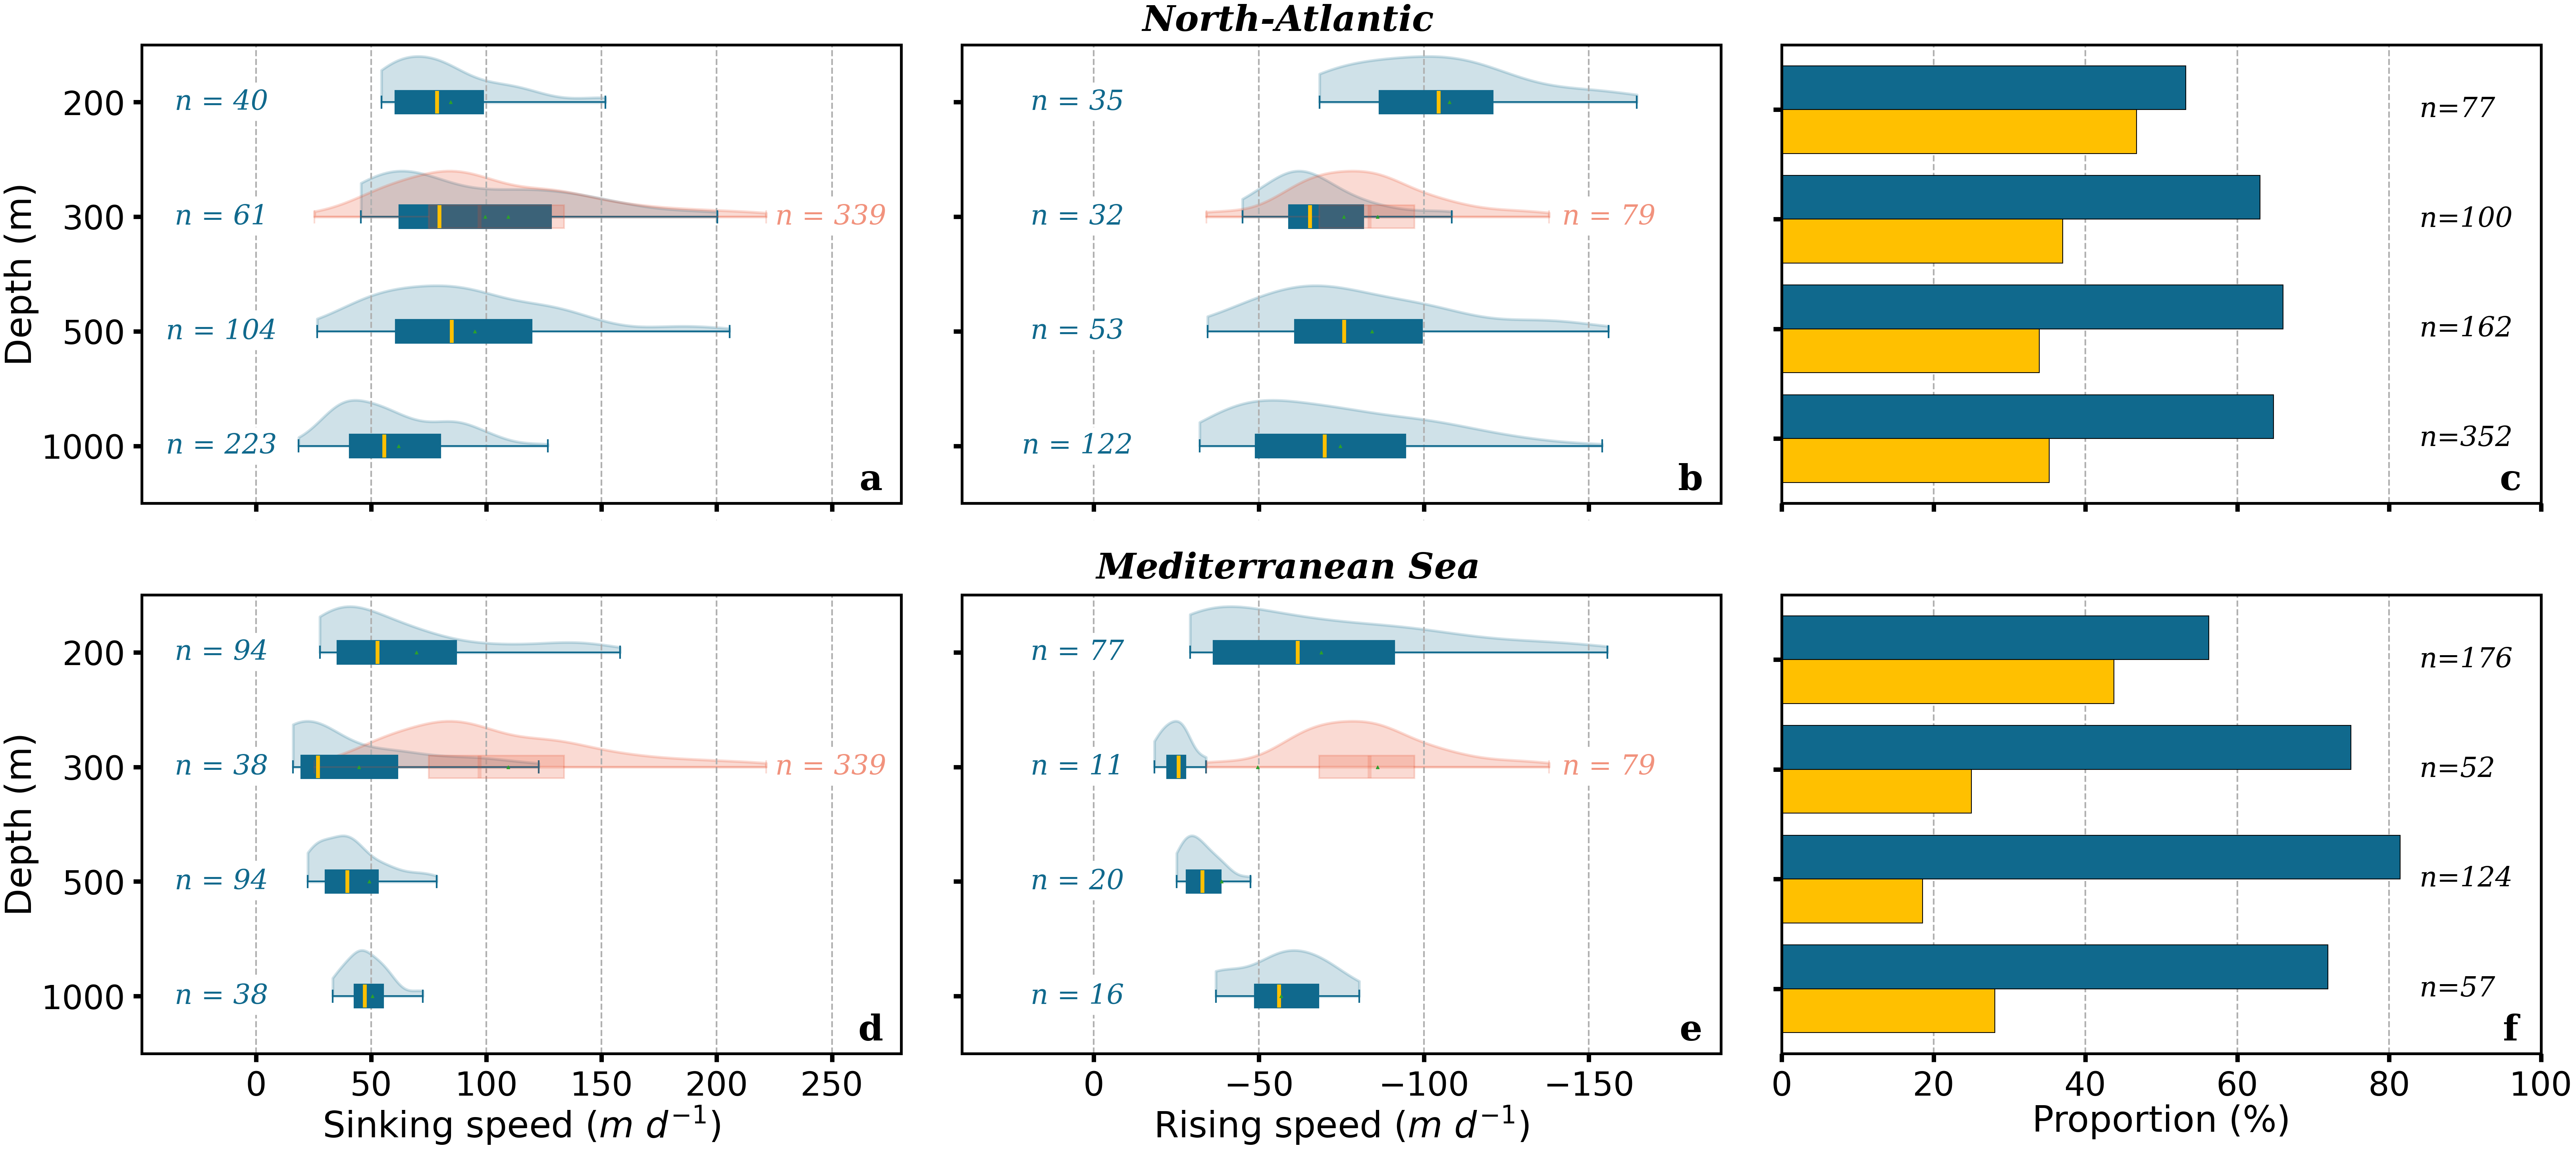

In [26]:
fig, axs = plt.subplots(2, 3, figsize=(65, 30))

x_l_limit_desc = -49.5
x_u_limit_desc = 280

x_l_limit_asc = 40
x_u_limit_asc = -190

# Plot in position 0,0
boxplot('corrected_by_poly', 'depth', desc_depth_APERO, MBARI_desc, mbari_alpha = 0.2, x_label = 'Sinking speed ($m$ $d^{-1}$)', y_label = 'Depth (m)', x_l_limit = x_l_limit_desc, x_u_limit = x_u_limit_desc, ax = axs[0,0], subplot_indice = 'a', show_xticks = False, show_yticks = True)

# Plot in position 0,1
boxplot('corrected_by_poly', 'depth', asc_depth_APERO, MBARI_asc, mbari_alpha = 0.2, x_label = 'Rising speed ($m$ $d^{-1}$)', y_label = '', x_l_limit = x_l_limit_asc, x_u_limit = x_u_limit_asc, ax=axs[0,1], subplot_indice = 'b', show_xticks = False, show_yticks = False)

# Plot in position 0,2
plot_horizontal_bar_proportions(nb_part_tot_APERO, 
                                x_label='Proportion (%)', 
                                y_label='Depth (m)', subplot_indice = 'c',  
                                show_xticks=False, show_yticks=False, 
                                ax=axs[0,2])

# Plot in position 1,0
boxplot('corrected_by_poly', 'depth', desc_depth_VLFR, MBARI_desc, mbari_alpha = 0.2, x_label = 'Sinking speed ($m$ $d^{-1}$)', y_label = 'Depth (m)', x_l_limit = x_l_limit_desc, x_u_limit = x_u_limit_desc, ax = axs[1,0], subplot_indice = 'd', show_xticks = True, show_yticks = True)

# Plot in position 0,1
boxplot('corrected_by_poly', 'depth', asc_depth_VLFR, MBARI_asc, mbari_alpha = 0.2, x_label = 'Rising speed ($m$ $d^{-1}$)', y_label = '', x_l_limit = x_l_limit_asc, x_u_limit = x_u_limit_asc, ax=axs[1,1], subplot_indice = 'e', show_xticks = True, show_yticks = False)

# Plot in position 0,2
plot_horizontal_bar_proportions(nb_part_tot_VLFR, 
                                x_label='Proportion (%)', 
                                y_label='Depth (m)', subplot_indice = 'f',
                                show_xticks=True, show_yticks=False, 
                                ax=axs[1,2])

# Legend 
#mean_line = mlines.Line2D([], [], color='black', linestyle=(0, (1, 1)), linewidth=15, label='Mean')
median_line = mlines.Line2D([], [], color='black', linestyle='-', linewidth=15, label='Median')
#fig.legend(handles=[median_line], loc='upper center', ncol=2, fontsize=50, frameon=False)

fig.text(0.5, 0.95, 'North-Atlantic', fontsize=65, fontweight = 'bold', fontstyle='italic', fontfamily = 'serif', va='center', ha = 'center', rotation='horizontal')
fig.text(0.5, 0.49, 'Mediterranean Sea', fontsize=65, fontweight = 'bold', fontstyle='italic', fontfamily = 'serif', va='center', ha = 'center', rotation='horizontal')

plt.tight_layout(rect=[0, 0, 1, 1])
plt.subplots_adjust(top=0.93, wspace=0.08, hspace = 0.2)

# Save the figure
plt.savefig(f'/home/aaccardo/these_alex/Papers/Rising_stars/Figure_S7/Figure_S7.png', dpi = 300)

plt.show()